In [1]:
import sys; sys.path.append("../src")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from skimage import color
from data import load_folds, IMG_DIR

In [2]:
f = load_folds()
trn = f[~f["is_test"]]          # never EDA on test
print(len(trn), trn["Species"].nunique())

13274 9


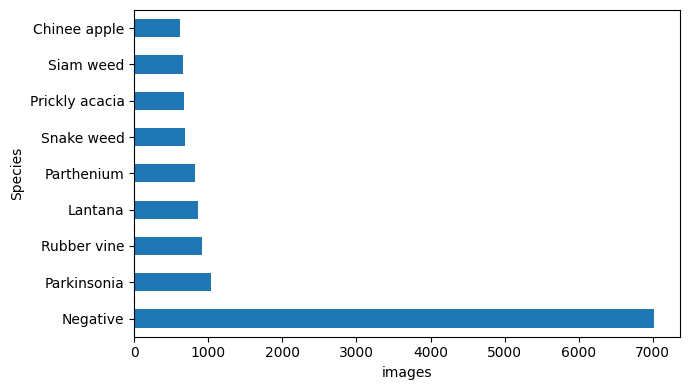

In [3]:
ax = trn["Species"].value_counts().plot.barh(figsize=(7,4))
ax.set_xlabel("images"); plt.tight_layout()
plt.savefig("../figures/class_dist.png", dpi=150); plt.show()

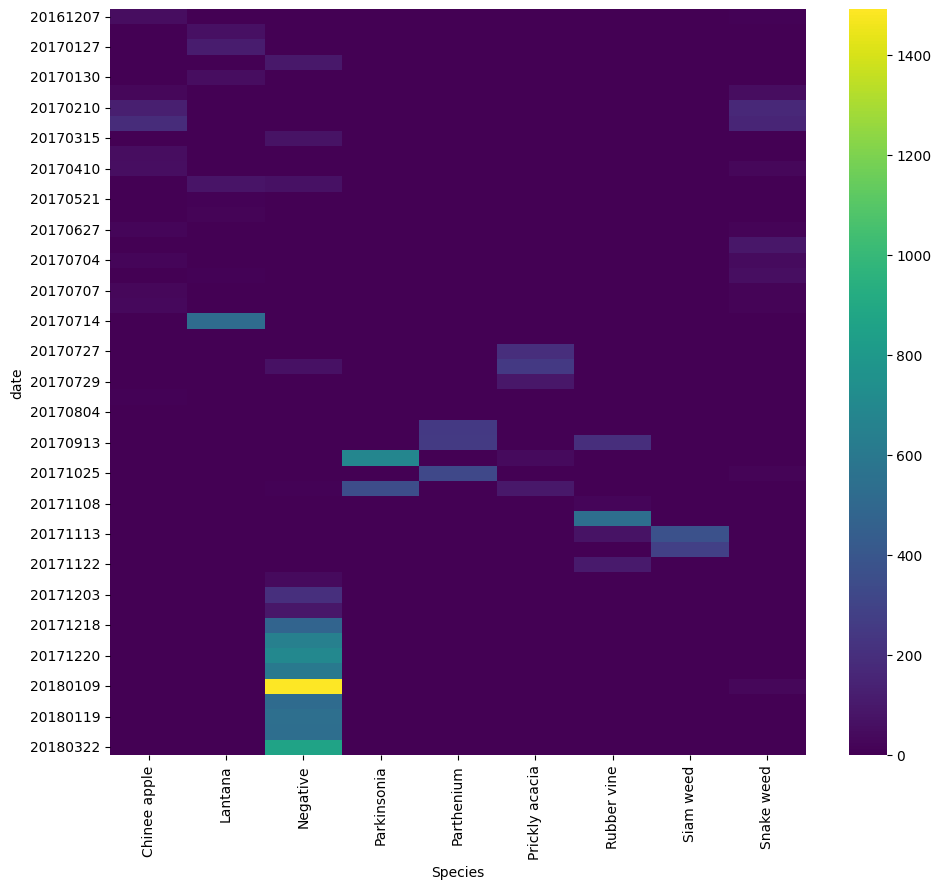

In [4]:
ct = pd.crosstab(trn["date"], trn["Species"])
plt.figure(figsize=(10,9)); sns.heatmap(ct, cmap="viridis")
plt.tight_layout(); plt.savefig("../figures/species_by_date.png", dpi=150); plt.show()

count     80.000000
mean     165.925000
std      155.262357
min        3.000000
25%       49.750000
50%      127.000000
75%      233.250000
max      879.000000
dtype: float64


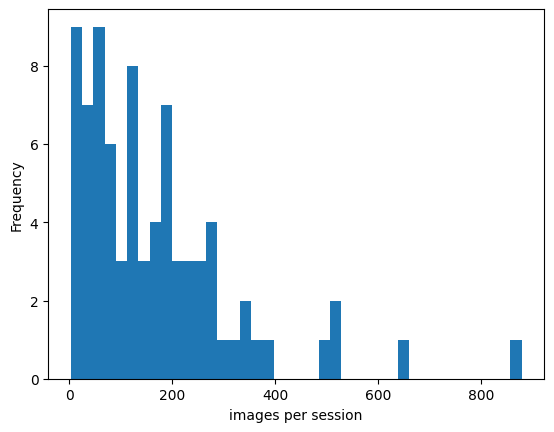

In [5]:
s = trn.groupby("session").size()
print(s.describe())
s.plot.hist(bins=40); plt.xlabel("images per session")
plt.savefig("../figures/session_sizes.png", dpi=150); plt.show()

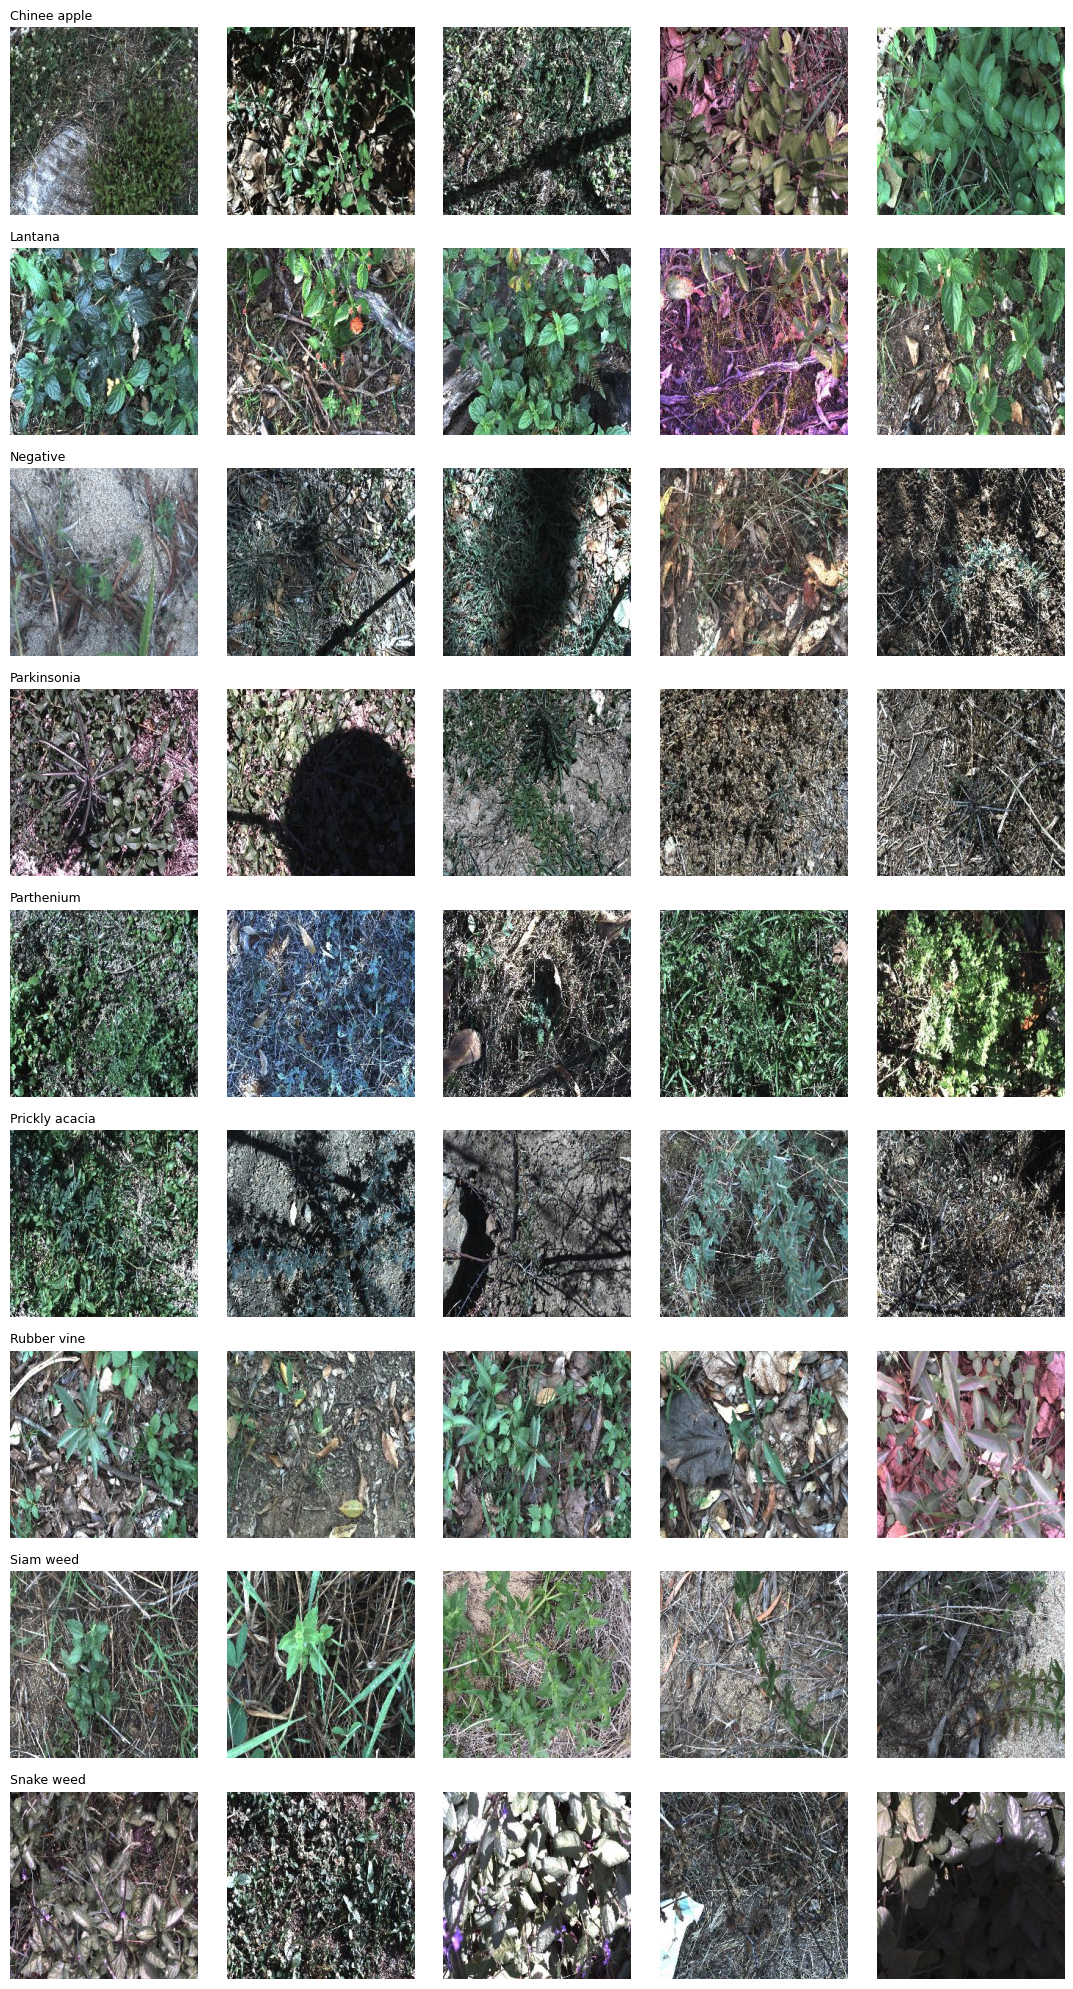

In [6]:
fig, axes = plt.subplots(9, 5, figsize=(11, 20))
for r, sp in enumerate(sorted(trn["Species"].unique())):
    sub = trn[trn["Species"] == sp].sample(5, random_state=0)
    for c, fn in enumerate(sub["Filename"]):
        axes[r,c].imshow(Image.open(IMG_DIR/fn)); axes[r,c].axis("off")
    axes[r,0].set_title(sp, loc="left", fontsize=9)
plt.tight_layout(); plt.savefig("../figures/samples.png", dpi=150)

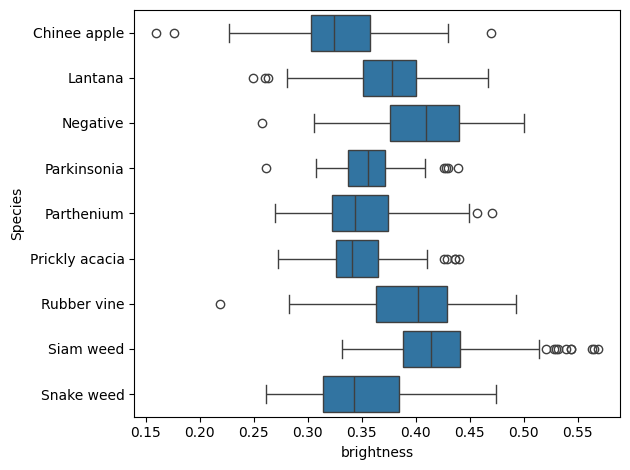

In [9]:
rows = []
for _, r in trn.groupby("Species").sample(150, random_state=0).iterrows():
    a = np.asarray(Image.open(IMG_DIR/r.Filename).convert("RGB").resize((64,64)))/255.
    h = color.rgb2hsv(a)
    rows.append({"Species": r.Species, "brightness": a.mean(),
                 "hue": h[...,0].mean(), "sat": h[...,1].mean()})
e = pd.DataFrame(rows)
sns.boxplot(data=e, y="Species", x="brightness"); plt.tight_layout()
plt.savefig("../figures/brightness_by_class.png", dpi=150); plt.show()